# Exploratory Data Analysis — CDC BRFSS 2015
### Hari Vykuntapu | MS Artificial Intelligence, Southwest Baptist University

---

**Research Question:** Can financial stress — income level, inability to afford healthcare, and employment instability — predict heart disease risk in Americans?

Most heart disease models I’ve read demand clinical inputs. Mine starts somewhere different: with economic pressure. In this notebook I dig into the CDC BRFSS 2015 survey to see whether financial hardship variables actually track with who ends up with heart disease.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 150

os.makedirs('../outputs/eda', exist_ok=True)

## 1. Load the Raw Dataset

The BRFSS is a national phone survey run by the CDC every year — 400,000+ interviews across all 50 states. The breadth is what makes it useful here: enough respondents to see clean population-level patterns in the financial variables I care about.


In [2]:
df = pd.read_csv('../data/raw/2015.csv', low_memory=False)
print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}')

Dataset shape: (441456, 330)
Rows: 441,456 | Columns: 330


## 2. Data Overview — Shape, Types, Nulls

Before filtering anything, I want to understand what’s actually here — which columns have real coverage and which are mostly empty. That shapes what I can use.


In [3]:
print('=== DATA TYPES ===')
print(df.dtypes.value_counts())
print()
print('=== SAMPLE COLUMNS ===')
print(df.columns[:20].tolist())

=== DATA TYPES ===
float64    323
str          7
Name: count, dtype: int64

=== SAMPLE COLUMNS ===
['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES', 'CELLFON3', 'LADULT', 'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'CTELNUM1', 'CELLFON2']


In [4]:
cols_of_interest = ['_MICHD', 'INCOME2', 'MEDCOST', 'EMPLOY1', '_BMI5', 'SMOKE100', '_AGE80', 'SEX', 'DIABETE3']

# Check which columns exist
available_cols = [c for c in cols_of_interest if c in df.columns]
missing_cols = [c for c in cols_of_interest if c not in df.columns]
print(f'Available columns: {available_cols}')
print(f'Missing columns: {missing_cols}')

Available columns: ['_MICHD', 'INCOME2', 'MEDCOST', 'EMPLOY1', '_BMI5', 'SMOKE100', '_AGE80', 'SEX', 'DIABETE3']
Missing columns: []


In [5]:
df_subset = df[available_cols].copy()

# Rename computed variable to clean target name used throughout
df_subset = df_subset.rename(columns={'_MICHD': 'MICHD'})

null_report = pd.DataFrame({
    'Column': df_subset.columns,
    'Null Count': df_subset.isnull().sum().values,
    'Null %': (df_subset.isnull().sum().values / len(df_subset) * 100).round(2)
})
print('=== NULL REPORT ===')
print(null_report.to_string(index=False))

=== NULL REPORT ===
  Column  Null Count  Null %
   MICHD        3942    0.89
 INCOME2        3301    0.75
 MEDCOST           1    0.00
 EMPLOY1           0    0.00
   _BMI5       36398    8.24
SMOKE100       14255    3.23
  _AGE80           0    0.00
     SEX           0    0.00
DIABETE3           7    0.00


## 3. Filter to Relevant Columns and Drop Critical Nulls

I need four columns intact: `MICHD` (heart disease outcome), `INCOME2`, `MEDCOST`, and `EMPLOY1`. Any row missing one of these gets dropped. With 400K+ rows, I can afford to be strict here rather than impute.


In [6]:
critical_cols = [c for c in ['MICHD', 'INCOME2', 'MEDCOST', 'EMPLOY1'] if c in df_subset.columns]
df_clean = df_subset.dropna(subset=critical_cols).copy()
print(f'Before dropping nulls: {df_subset.shape[0]:,} rows')
print(f'After dropping nulls:  {df_clean.shape[0]:,} rows')
print(f'Rows retained: {df_clean.shape[0]/df_subset.shape[0]*100:.1f}%')

Before dropping nulls: 441,456 rows
After dropping nulls:  434,256 rows
Rows retained: 98.4%


## 4. Variable Recoding

CDC survey codes aren't analysis-ready as-is. MICHD=1 means heart disease, MICHD=2 means no heart disease. MEDCOST=1 means couldn't afford care, MEDCOST=2 means no problem. I recode everything to 0/1 binary following the CDC codebook, and collapse the 8-level EMPLOY1 variable into three groups: employed, unemployed, and other (homemaker / retired / student / unable to work).


In [7]:
# MICHD: 1 = ever had heart disease/heart attack, 2 = no
if 'MICHD' in df_clean.columns:
    df_clean['MICHD'] = df_clean['MICHD'].map({1: 1, 2: 0})
    print('MICHD distribution (1=heart disease, 0=none):')
    print(df_clean['MICHD'].value_counts())
    print(f'Heart disease prevalence: {df_clean["MICHD"].mean()*100:.2f}%')

MICHD distribution (1=heart disease, 0=none):
MICHD
0    395854
1     38402
Name: count, dtype: int64
Heart disease prevalence: 8.84%


In [8]:
# MEDCOST: 1 = could not see doctor due to cost, 2 = no issue
if 'MEDCOST' in df_clean.columns:
    df_clean['MEDCOST'] = df_clean['MEDCOST'].map({1: 1, 2: 0})
    print('MEDCOST distribution (1=cannot afford, 0=can afford):')
    print(df_clean['MEDCOST'].value_counts())

MEDCOST distribution (1=cannot afford, 0=can afford):
MEDCOST
0.0    390646
1.0     42507
Name: count, dtype: int64


In [9]:
# EMPLOY1: 1=employed for wages, 2=self-employed, 3=out of work >1yr, 4=out of work <1yr, 5=homemaker, 6=student, 7=retired, 8=unable to work
if 'EMPLOY1' in df_clean.columns:
    employ_map = {1: 1, 2: 1, 3: 2, 4: 2, 5: 3, 6: 3, 7: 3, 8: 3}
    df_clean['EMPLOY1'] = df_clean['EMPLOY1'].map(employ_map)
    df_clean['EMPLOY1'] = df_clean['EMPLOY1'].fillna(3)
    print('EMPLOY1 distribution (1=employed, 2=unemployed, 3=other):')
    print(df_clean['EMPLOY1'].value_counts())

EMPLOY1 distribution (1=employed, 2=unemployed, 3=other):
EMPLOY1
1.0    213135
3.0    202845
2.0     18276
Name: count, dtype: int64


In [10]:
# Drop remaining rows with NaN after recoding (due to unmapped codes)
df_clean = df_clean.dropna(subset=['MICHD', 'MEDCOST']).copy()
df_clean['MICHD'] = df_clean['MICHD'].astype(int)
df_clean['MEDCOST'] = df_clean['MEDCOST'].astype(int)
print(f'\nFinal clean dataset: {df_clean.shape[0]:,} rows')


Final clean dataset: 433,153 rows


## 5. Target Variable — Heart Disease Prevalence

How common is heart disease in this sample? The BRFSS is a population survey, not a clinical cohort, so I expect a low positive rate. The exact number matters because severe class imbalance — say, 5% positive — changes what metrics mean and what training tricks I'll need.


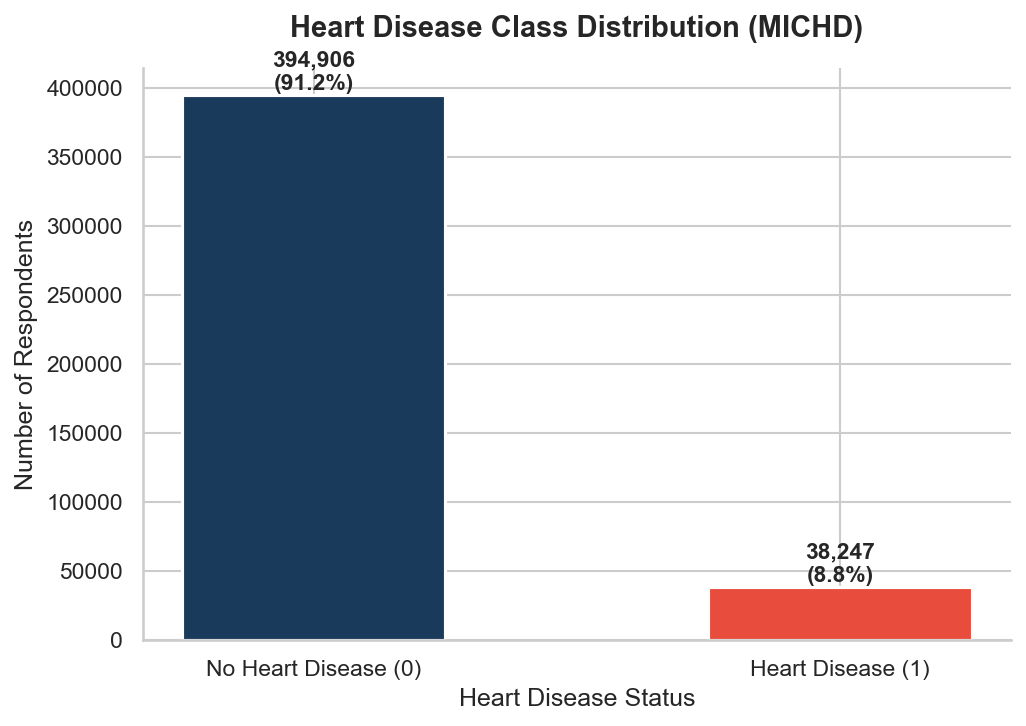

Saved: outputs/eda/class_distribution.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = df_clean['MICHD'].value_counts()
colors = ['#1a3a5c', '#e74c3c']
bars = ax.bar(['No Heart Disease (0)', 'Heart Disease (1)'], counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{count:,}\n({count/len(df_clean)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Heart Disease Class Distribution (MICHD)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Respondents', fontsize=12)
ax.set_xlabel('Heart Disease Status', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/eda/class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/eda/class_distribution.png')

## 6. Heart Disease Rate by Income Level

`INCOME2` runs 1–8, from under $10K to over $75K/year. If financial pressure is genuinely upstream of cardiovascular health, the pattern should be obvious: lower income, higher heart disease rate. Let’s see if the data agrees.


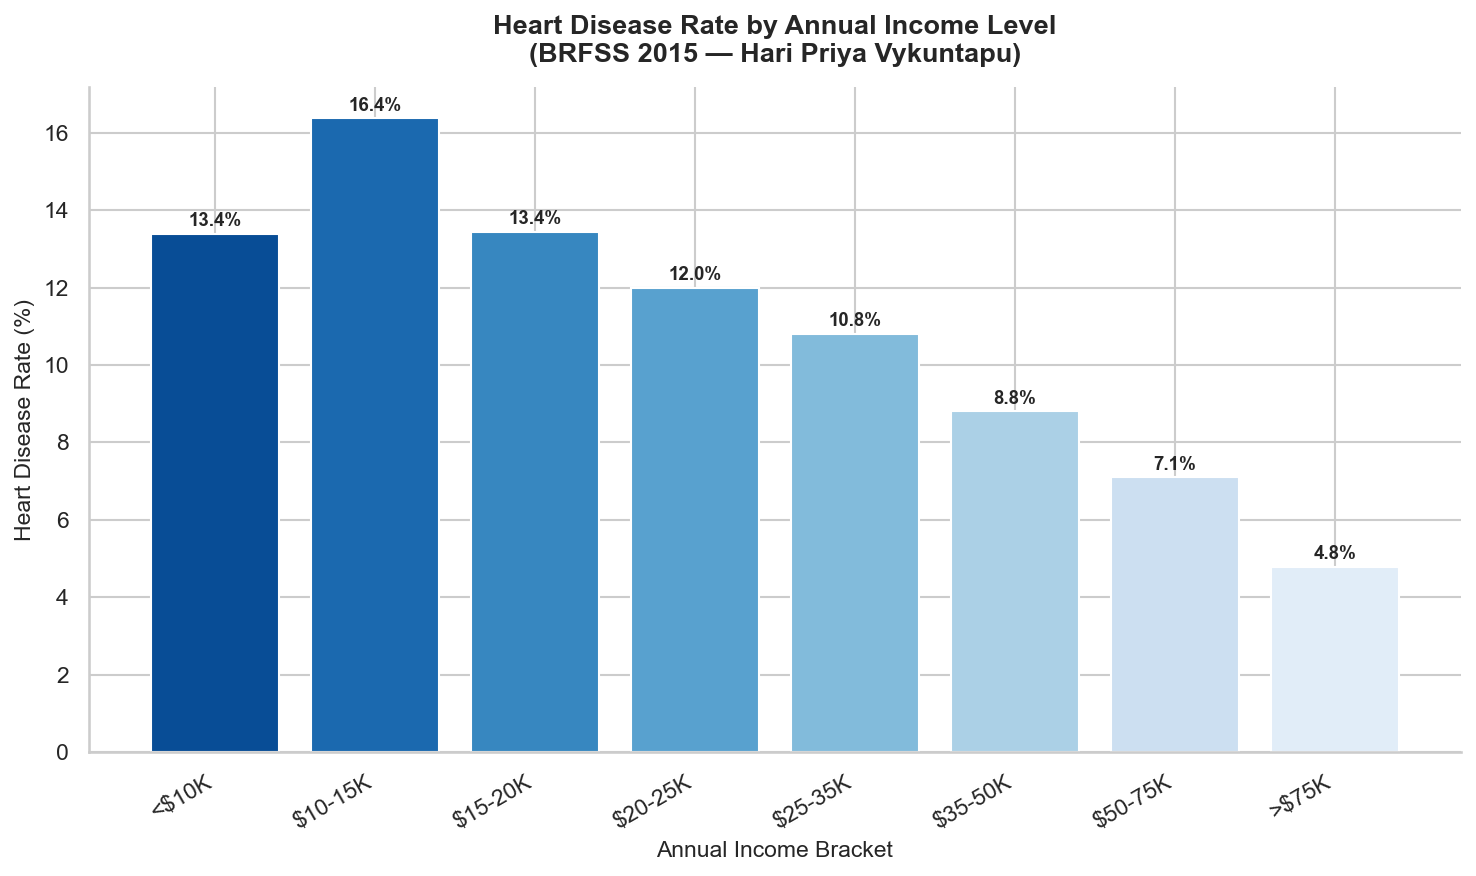

Saved: outputs/eda/hd_rate_by_income.png


In [12]:
income_labels = {
    1: '<$10K', 2: '$10-15K', 3: '$15-20K', 4: '$20-25K',
    5: '$25-35K', 6: '$35-50K', 7: '$50-75K', 8: '>$75K'
}

if 'INCOME2' in df_clean.columns:
    income_hd = df_clean[df_clean['INCOME2'].isin(income_labels.keys())].groupby('INCOME2')['MICHD'].mean() * 100
    income_hd.index = income_hd.index.map(income_labels)

    fig, ax = plt.subplots(figsize=(10, 6))
    palette = sns.color_palette('Blues_r', len(income_hd))
    bars = ax.bar(income_hd.index, income_hd.values, color=palette, edgecolor='white', linewidth=1)

    for bar, val in zip(bars, income_hd.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title('Heart Disease Rate by Annual Income Level\n(BRFSS 2015 — Hari Vykuntapu)', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Annual Income Bracket', fontsize=11)
    ax.set_ylabel('Heart Disease Rate (%)', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('../outputs/eda/hd_rate_by_income.png', bbox_inches='tight')
    plt.show()
    print('Saved: outputs/eda/hd_rate_by_income.png')

## 7. Heart Disease Rate by Healthcare Affordability

This is the most direct financial barrier in the dataset. People who skipped the doctor because of cost are exactly the people least likely to catch early warning signs — high blood pressure, pre-diabetes, arrhythmia — before they become something worse. I expect a clear difference in heart disease rates between the two groups.


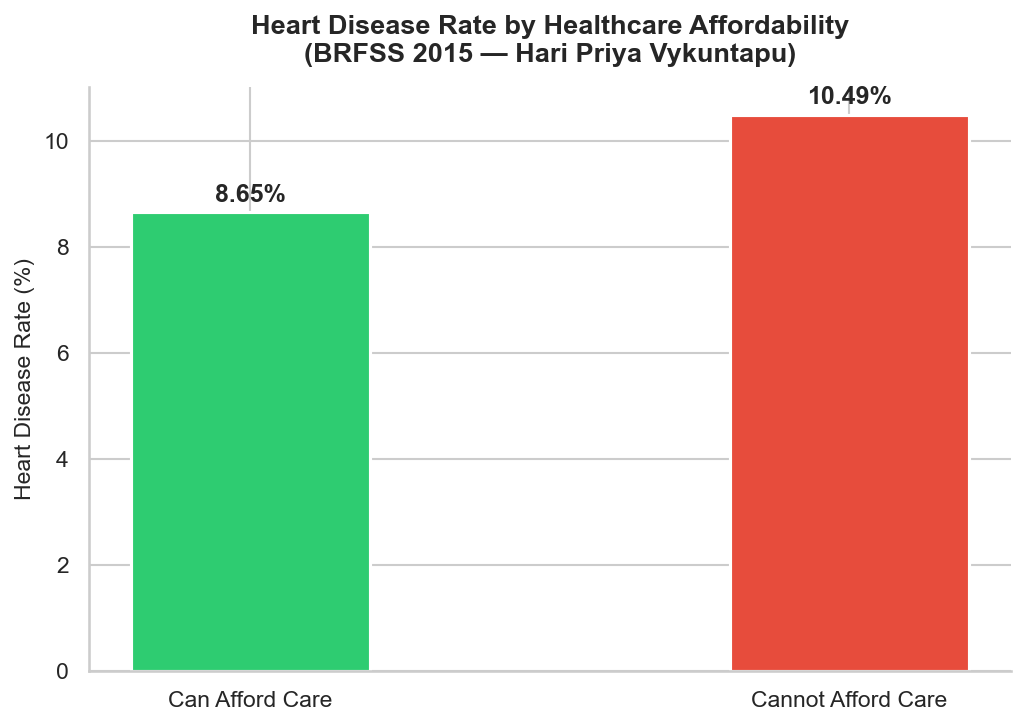

Saved: outputs/eda/hd_rate_by_medcost.png


In [13]:
if 'MEDCOST' in df_clean.columns:
    medcost_hd = df_clean.groupby('MEDCOST')['MICHD'].mean() * 100
    medcost_labels = {0: 'Can Afford Care', 1: 'Cannot Afford Care'}
    medcost_hd.index = medcost_hd.index.map(medcost_labels)

    fig, ax = plt.subplots(figsize=(7, 5))
    colors = ['#2ecc71', '#e74c3c']
    bars = ax.bar(medcost_hd.index, medcost_hd.values, color=colors, width=0.4, edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, medcost_hd.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_title('Heart Disease Rate by Healthcare Affordability\n(BRFSS 2015 — Hari Vykuntapu)', fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Heart Disease Rate (%)', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('../outputs/eda/hd_rate_by_medcost.png', bbox_inches='tight')
    plt.show()
    print('Saved: outputs/eda/hd_rate_by_medcost.png')

## 8. Heart Disease Rate by Employment Status

Unemployment isn’t just a financial hit — it usually means losing employer health insurance too. I want to know whether that translates into higher cardiovascular rates in this data, or whether income and affordability already capture most of that signal.


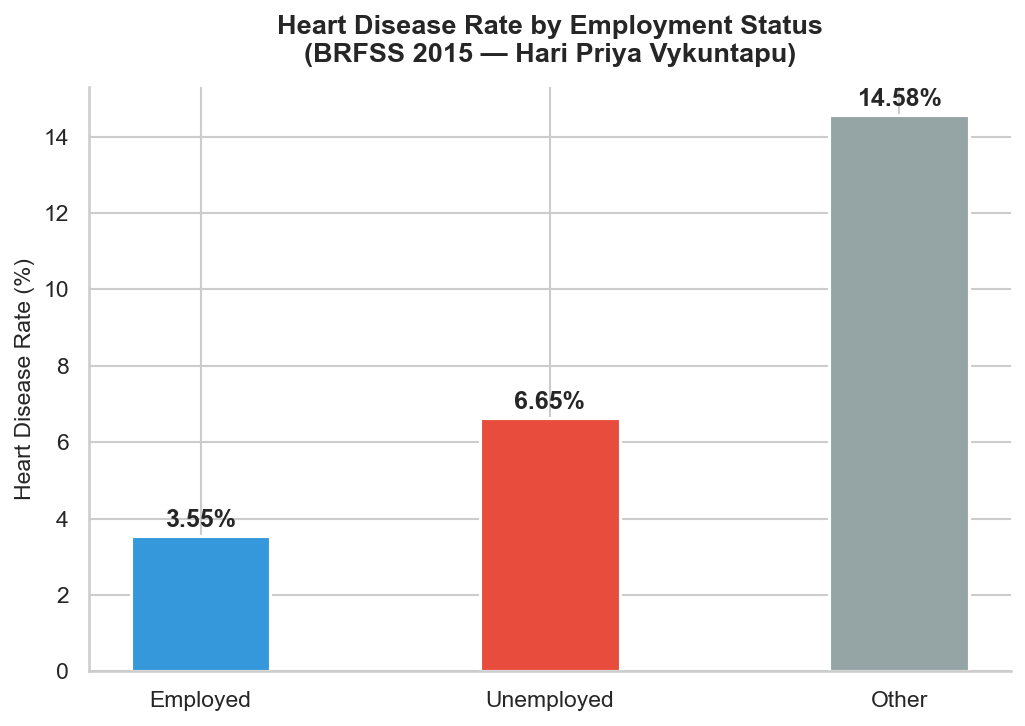

Saved: outputs/eda/hd_rate_by_employment.png


In [14]:
if 'EMPLOY1' in df_clean.columns:
    employ_hd = df_clean.groupby('EMPLOY1')['MICHD'].mean() * 100
    employ_labels = {1.0: 'Employed', 2.0: 'Unemployed', 3.0: 'Other'}
    employ_hd.index = employ_hd.index.map(employ_labels)
    employ_hd = employ_hd.dropna()

    fig, ax = plt.subplots(figsize=(7, 5))
    colors = ['#3498db', '#e74c3c', '#95a5a6']
    bars = ax.bar(employ_hd.index, employ_hd.values, color=colors[:len(employ_hd)], width=0.4, edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, employ_hd.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_title('Heart Disease Rate by Employment Status\n(BRFSS 2015 — Hari Vykuntapu)', fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Heart Disease Rate (%)', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('../outputs/eda/hd_rate_by_employment.png', bbox_inches='tight')
    plt.show()
    print('Saved: outputs/eda/hd_rate_by_employment.png')

## 9. Save Cleaned Dataset

Saving the recoded dataset before moving on. Notebook 02 picks this up and builds the Financial Stress Score on top of it.


In [15]:
df_clean.to_csv('../data/processed/brfss_cleaned.csv', index=False)
print(f'Saved cleaned dataset: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')
print('Location: data/processed/brfss_cleaned.csv')
print()
print('=== FINAL COLUMN SUMMARY ===')
print(df_clean.describe().round(3))

Saved cleaned dataset: 433,153 rows x 9 columns
Location: data/processed/brfss_cleaned.csv

=== FINAL COLUMN SUMMARY ===
            MICHD     INCOME2     MEDCOST     EMPLOY1       _BMI5    SMOKE100  \
count  433153.000  433153.000  433153.000  433153.000  400658.000  422434.000   
mean        0.088      20.128       0.098       1.976    2803.542       1.614   
std         0.284      31.743       0.297       0.978     664.842       0.743   
min         0.000       1.000       0.000       1.000    1202.000       1.000   
25%         0.000       5.000       0.000       1.000    2373.000       1.000   
50%         0.000       7.000       0.000       2.000    2694.000       2.000   
75%         0.000       8.000       0.000       3.000    3090.000       2.000   
max         1.000      99.000       1.000       3.000    9995.000       9.000   

           _AGE80         SEX    DIABETE3  
count  433153.000  433153.000  433146.000  
mean       55.361       1.577       2.757  
std        17.021

---
## EDA Summary

The gradient is real. Lower income, no ability to afford care, unemployment — all three track with higher heart disease rates, consistently, across the full BRFSS sample. That’s the signal this project is built on.

Next step: compress those three dimensions into a single Financial Stress Score and test whether it holds up as a model feature.

*— Hari Vykuntapu, MS AI, Southwest Baptist University*
